In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
from main_toy import *
use_cuda = torch.cuda.is_available()
device    = 'cuda' if use_cuda else 'cpu'

In [2]:
#### data setting
dataseed = 42
n_samples = 8000
d = 10

def data_setting(d, dataseed):
    K = 4
    mean_constant = 3
    pi = torch.tensor([0.4, 0.3, 0.2, 0.1])
    pi = pi / pi.sum()
    means = torch.zeros(K,d)
    if K <= d+1:
        for i in range(K-1):
            means[i,i] = mean_constant
    else:
        for i in range(d):
            means[i,i] = mean_constant
        for i in range(min(d, K-d)):
            means[d+i,i] = -mean_constant
    covariances = random_covariances_qr(K, d, seed=dataseed)
    return pi, means, covariances

def generate_data(n_samples, d, dataseed):
    pi, means, covariances = data_setting(d, dataseed)
    data, z = sample_gmm(pi, means, covariances, n_samples=n_samples, seed=dataseed)
    data_np = data.numpy()
    return data_np

In [3]:
np.random.seed(0)

In [4]:
res_set = {}

In [74]:
def display_samples_np(ax, x, color, axis0=0, axis1=1, setlim=False, set_xlabel=True, set_ylabel=True, fontsize=8, no_tick_labels=False):
    ax.scatter( x[:,axis0], x[:,axis1], 25*500 / len(x), color, edgecolors='none' )
    if set_xlabel:
        ax.set_xlabel(r'$x_1$', fontsize=fontsize)
    if set_ylabel:
        ax.set_ylabel(r'$x_2$', fontsize=fontsize)
    else:
        plt.gca().set_yticklabels([])
    if no_tick_labels:
        plt.gca().set_xticklabels([])
        plt.gca().set_yticklabels([])
    else:
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
    if setlim:
        ax.set_xlim([-7,9])
        ax.set_ylim([-4.5,6.75])
    else:
        ax.axis('equal')

In [6]:
bs_set = [32, 64, 128, 256, 512, 1024]
seeds = [0,1,2,3]
dims = [2, 5, 10]
for d in dims:
    for bs in bs_set:
        for s in seeds:
            foldername = f'GMMd{d}K4stream_bs{bs}_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4stream_bs{bs}_a0.5_L1_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4stream_bs{bs}_a0.5_L5_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_a0.5_L1_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_a0.5_L5_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)

In [7]:
bs_set = [32, 64, 128, 256, 512, 1024]
seeds = [0,1,2,3]
dims = [2, 5, 10]
for d in dims:
    for bs in bs_set:
        for s in seeds:
            foldername = f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_a0.5_L5_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)
            foldername = f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_a0.5_L5_AdamW'
            with open(f"./output/{foldername}/results_s{s}ds42.pickle", "rb") as f:
                res_set[foldername+f'_s{s}'] = pickle.load(f)

In [10]:
z_dim = 10

In [13]:
sliced_wass_set = {}

In [14]:
bs_set = [32, 64, 128, 256, 512, 1024]
dims=[2, 5, 10]
n_samples3 = 100000
for d in dims:
    data = torch.FloatTensor(generate_data(n_samples3, d, dataseed)).to(device)
    for bs in bs_set:
        # for foldername in [f'GMMd{d}K4_bs{bs}_AdamW', f'GMMd{d}K4_bs{bs}_a0.5_L1_AdamW']:
        for foldername in [f'GMMd{d}K4_bs{bs}_AdamW', f'GMMd{d}K4_bs{bs}_a0.5_L1_AdamW', 
                          f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_AdamW', f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW',
                          f'GMMd{d}K4stream_bs{bs}_AdamW', f'GMMd{d}K4stream_bs{bs}_a0.5_L1_AdamW', 
                          f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_AdamW', f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW']:
            temp_dist0 = []
            for s in [0,1,2,3]:
                cur_dev = next(res_set[foldername+f'_s{s}']['net'].parameters()).device
                mb_x = torch.randn(n_samples3, z_dim).type(torch.FloatTensor).to(cur_dev)
                f_x = res_set[foldername+f'_s{s}']['net'](mb_x)
                data = data.to(cur_dev)
                sw, th = sliced_wasserstein(data, f_x, n_proj=1000)
                temp_dist0.append(sw.item())
            sliced_wass_set[foldername] = temp_dist0

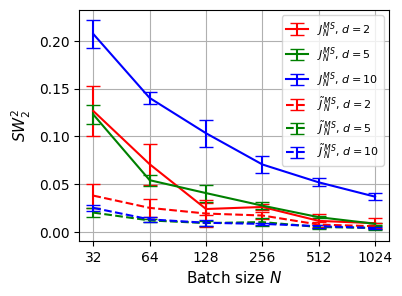

In [121]:
dims=[2,5,10]
bs_set=[32,64,128,256,512,1024]
colors = ['r', 'g', 'b', 'm', 'y', 'c']
ls_set = ['solid', '--', '-.', ':']
titles = ['online', 'fixdata']
ls = '-'
stream=''
stream='stream'
sinkhorn=''
L = 1
seeds = [0,1,2,3]
plt.figure(figsize=(4,3))
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
        temp_means.append(np.mean(sliced_wass_set[foldername]))
        temp_stds.append(np.std(sliced_wass_set[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[0], label=r"$J^{MS}_{N}$, " + f"$ d={d}$", capsize=5)

for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
        temp_means.append(np.mean(sliced_wass_set[foldername]))
        temp_stds.append(np.std(sliced_wass_set[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[1], label=r"$\tilde J^{MS}_{N}$, " + f"$ d={d}$", capsize=5)
plt.legend(fontsize=8)
fontsize=11
plt.ylabel(r'$SW_2^2$', fontsize=fontsize)
plt.xlabel(r'Batch size $N$', fontsize=fontsize)
plt.grid()
plt.xticks([i for i in range(len(bs_set))], bs_set)
plt.savefig(f'./fig_swd_nngenerator.pdf', format='pdf', bbox_inches="tight", dpi=300)

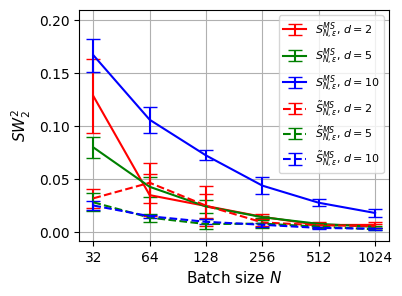

In [128]:
dims=[2,5,10]
bs_set=[32,64,128,256,512,1024]
colors = ['r', 'g', 'b', 'm', 'y', 'c']
ls_set = ['solid', '--', '-.', ':']
titles = ['online', 'fixdata']
ls = '-'
stream='stream'
sinkhorn='_sinkhornReg1.0'
L = 1
seeds = [0,1,2,3]
plt.figure(figsize=(4,3))
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
        temp_means.append(np.mean(sliced_wass_set[foldername]))
        temp_stds.append(np.std(sliced_wass_set[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[0], label=r"$S^{MS}_{N,\epsilon}$, " + f"$ d={d}$", capsize=5)
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
        temp_means.append(np.mean(sliced_wass_set[foldername]))
        temp_stds.append(np.std(sliced_wass_set[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[1], label=r"$\tilde S^{MS}_{N,\epsilon}$, " + f"$ d={d}$", capsize=5)
plt.legend(fontsize=8)
fontsize=11
plt.ylabel(r'$SW_2^2$', fontsize=fontsize)
plt.xlabel(r'Batch size $N$', fontsize=fontsize)
plt.scatter(3,0.2,c='w')
plt.grid()
plt.xticks([i for i in range(len(bs_set))], bs_set)
plt.savefig(f'./fig_swd_nngenerator_sinkhorn.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [ ]:
cov_scale_set2 = {}
n_samples3 = 100000
bs_set = [32, 64, 128, 256, 512, 1024]
dims=[2, 5, 10]
for d in dims:
    data_np = generate_data(n_samples3, d, dataseed)
    for bs in bs_set:
        for foldername in [f'GMMd{d}K4_bs{bs}_AdamW', f'GMMd{d}K4_bs{bs}_a0.5_L1_AdamW', 
                          f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_AdamW', f'GMMd{d}K4_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW',
                          f'GMMd{d}K4stream_bs{bs}_AdamW', f'GMMd{d}K4stream_bs{bs}_a0.5_L1_AdamW', 
                          f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_AdamW', f'GMMd{d}K4stream_bs{bs}_sinkhornReg1.0_a0.5_L1_AdamW']:
            temp_scale0 = []
            for s in [0,1,2,3]:
                cur_dev = next(res_set[foldername+f'_s{s}']['net'].parameters()).device
                mb_x = torch.randn(n_samples3, z_dim).type(torch.FloatTensor).to(cur_dev)
                Y = res_set[foldername+f'_s{s}']['net'](mb_x).detach().cpu().numpy()
                temp_scale0.append(np.trace(np.cov(Y.T))/np.trace(np.cov(data_np.T)))
            cov_scale_set2[foldername] = temp_scale0

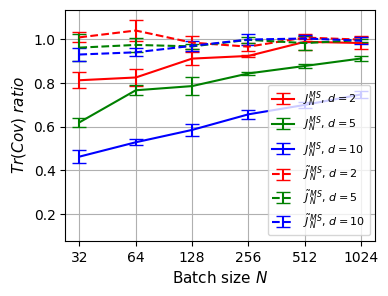

In [124]:
dims=[2,5,10]
bs_set=[32,64,128,256,512,1024]

colors = ['r', 'g', 'b', 'm', 'y', 'c']
ls_set = ['solid', '--', '-.', ':']
titles = ['online', 'fixdata']
ls = '-'
stream='stream'
sinkhorn=''
L = 1
seeds = [0,1,2,3]
plt.figure(figsize=(4,3))
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
        temp_means.append(np.mean(cov_scale_set2[foldername]))
        temp_stds.append(np.std(cov_scale_set2[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[0], label=r"$J^{MS}_{N}$, " + f"$ d={d}$", capsize=5)
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
        temp_means.append(np.mean(cov_scale_set2[foldername]))
        temp_stds.append(np.std(cov_scale_set2[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[1], label=r"$\tilde J^{MS}_{N}$, " + f"$ d={d}$", capsize=5)
plt.legend(fontsize=8)
fontsize=11
plt.ylabel(r'$Tr(Cov) \ ratio$', fontsize=fontsize)
plt.xlabel(r'Batch size $N$', fontsize=fontsize)
plt.scatter(3,0.125,c='w')
plt.grid()
plt.xticks([i for i in range(len(bs_set))], bs_set)
plt.savefig(f'./fig_trcov_nngenerator.pdf', format='pdf', bbox_inches="tight", dpi=300)

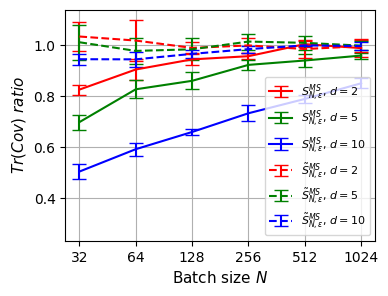

In [127]:
dims=[2,5,10]
bs_set=[32,64,128,256,512,1024]

colors = ['r', 'g', 'b', 'm', 'y', 'c']
# l_set = [0,1]
ls_set = ['solid', '--', '-.', ':']
titles = ['online', 'fixdata']
ls = '-'
stream='stream'
sinkhorn='_sinkhornReg1.0'
L = 1
seeds = [0,1,2,3]
plt.figure(figsize=(4,3))
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
        temp_means.append(np.mean(cov_scale_set2[foldername]))
        temp_stds.append(np.std(cov_scale_set2[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[0], label=r"$S^{MS}_{N,\epsilon}$, " + f"$ d={d}$", capsize=5)
for j, d in enumerate(dims):
    temp_means = []
    temp_stds = []
    for bs in bs_set:
        foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
        temp_means.append(np.mean(cov_scale_set2[foldername]))
        temp_stds.append(np.std(cov_scale_set2[foldername], ddof=0))
    plt.errorbar(np.arange(len(bs_set)), temp_means, 
                     yerr=temp_stds, color=colors[j], ls=ls_set[1], label=r"$\tilde S^{MS}_{N,\epsilon}$, " + f"$ d={d}$", capsize=5)
plt.legend(fontsize=8)
fontsize=11
plt.ylabel(r'$Tr(Cov) \ ratio$', fontsize=fontsize)
plt.xlabel(r'Batch size $N$', fontsize=fontsize)
plt.scatter(3,0.275,c='w')
plt.grid()
plt.xticks([i for i in range(len(bs_set))], bs_set)
plt.savefig(f'./fig_trcov_nngenerator_sinkhorn.pdf', format='pdf', bbox_inches="tight", dpi=300)

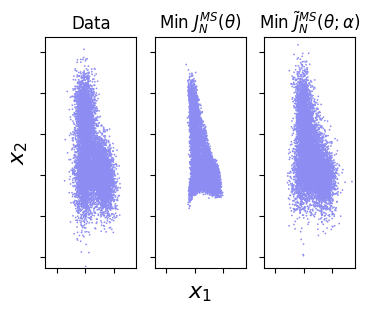

In [77]:
d=10
bs=64
axis0=0
axis1=1
stream=''
stream='stream'
s=0
data_np3 = generate_data(8000, d, dataseed)
fontsize=16
for axis1 in range(1,2):
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(1,3,1)
    display_samples_np(ax, data_np3, [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title('Data')
    ax = fig.add_subplot(1,3,2)
    foldername = f'GMMd{d}K4{stream}_bs{bs}_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $J^{MS}_N(\theta)$')
    ax = fig.add_subplot(1,3,3)
    foldername = f'GMMd{d}K4{stream}_bs{bs}_a0.5_L1_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $\tilde{J}^{MS}_N(\theta;\alpha)$')
    # fig.suptitle(f'Batch size = {bs}')
plt.savefig(f'./fig_bs64_nngenerator.pdf', format='pdf', bbox_inches="tight", dpi=300)

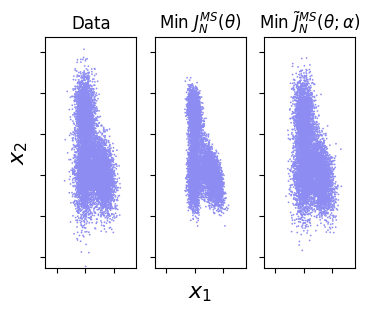

In [78]:
d=10
bs=1024
axis0=0
axis1=1
stream=''
stream='stream'
s=0
data_np3 = generate_data(8000, d, dataseed)
fontsize=16
for axis1 in range(1,2):
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(1,3,1)
    display_samples_np(ax, data_np3, [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title('Data')
    ax = fig.add_subplot(1,3,2)
    foldername = f'GMMd{d}K4{stream}_bs{bs}_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $J^{MS}_N(\theta)$')
    ax = fig.add_subplot(1,3,3)
    foldername = f'GMMd{d}K4{stream}_bs{bs}_a0.5_L1_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $\tilde{J}^{MS}_N(\theta;\alpha)$')
    # fig.suptitle(f'Batch size = {bs}')
plt.savefig(f'./fig_bs1024_nngenerator.pdf', format='pdf', bbox_inches="tight", dpi=300)

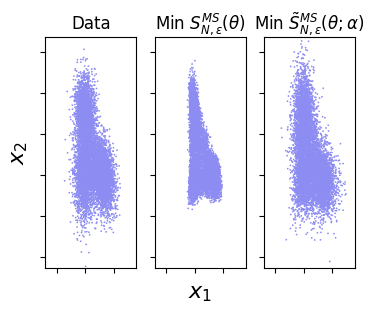

In [107]:
d=10
bs=64
axis0=0
axis1=1
stream=''
stream='stream'
sinkhorn='_sinkhornReg1.0'
s=0
data_np3 = generate_data(8000, d, dataseed)
fontsize=16
for axis1 in range(1,2):
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(1,3,1)
    display_samples_np(ax, data_np3, [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title('Data')
    ax = fig.add_subplot(1,3,2)
    foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $S^{MS}_{N,\epsilon}(\theta)$')
    ax = fig.add_subplot(1,3,3)
    foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $\tilde{S}^{MS}_{N,\epsilon}(\theta;\alpha)$')
    # fig.suptitle(f'Batch size = {bs}')
plt.savefig(f'./fig_bs64_nngenerator_sinkhorn.pdf', format='pdf', bbox_inches="tight", dpi=300)

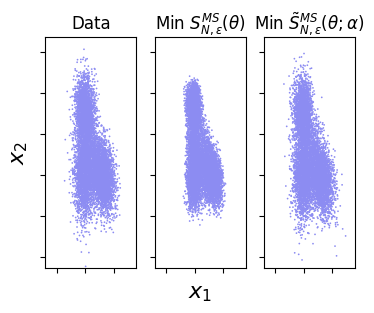

In [108]:
d=10
bs=1024
axis0=0
axis1=1
stream=''
stream='stream'
sinkhorn='_sinkhornReg1.0'
s=0
data_np3 = generate_data(8000, d, dataseed)
fontsize=16
for axis1 in range(1,2):
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(1,3,1)
    display_samples_np(ax, data_np3, [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title('Data')
    ax = fig.add_subplot(1,3,2)
    foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $S^{MS}_{N,\epsilon}(\theta)$')
    ax = fig.add_subplot(1,3,3)
    foldername = f'GMMd{d}K4{stream}_bs{bs}{sinkhorn}_a0.5_L1_AdamW'
    display_samples_np(ax, res_set[foldername+f'_s{s}'][f'fx_set'][-1], [(.55,.55,.95)], axis0=axis0, axis1=axis1, setlim=True, set_xlabel=False, set_ylabel=False, no_tick_labels=True, fontsize=fontsize)
    ax.set_title(r'Min $\tilde{S}^{MS}_{N,\epsilon}(\theta;\alpha)$')
    # fig.suptitle(f'Batch size = {bs}')
plt.savefig(f'./fig_bs1024_nngenerator_sinkhorn.pdf', format='pdf', bbox_inches="tight", dpi=300)